In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [2]:
original_df=pd.read_csv("with_login.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.shape

(4461, 15)

In [5]:
df.isna().sum()

company_size               0
is_premium                 0
subscription_status        0
jobma_catcher_status       0
sub_users                  0
wallet_amount              0
is_unlimited               0
plan_type                  0
subscription_count         0
invitations                0
pre_recorded_kit_counts    0
number_of_jobs_posted      0
pre_rec_interview_taken    0
subscription_amount_usd    0
days_since_login           0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4461 entries, 0 to 4460
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4461 non-null   object 
 1   is_premium               4461 non-null   int64  
 2   subscription_status      4461 non-null   int64  
 3   jobma_catcher_status     4461 non-null   int64  
 4   sub_users                4461 non-null   int64  
 5   wallet_amount            4461 non-null   float64
 6   is_unlimited             4461 non-null   int64  
 7   plan_type                4461 non-null   int64  
 8   subscription_count       4461 non-null   int64  
 9   invitations              4461 non-null   int64  
 10  pre_recorded_kit_counts  4461 non-null   int64  
 11  number_of_jobs_posted    4461 non-null   int64  
 12  pre_rec_interview_taken  4461 non-null   int64  
 13  subscription_amount_usd  4461 non-null   float64
 14  days_since_login        

In [7]:
binary_columns = ['is_premium',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]

categorical_columns =['company_size',
                      'days_since_login']
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken',
                    'days_since_login',
                   ]

ordinal_columns =['subscription_amount_usd']

In [8]:
# Removing negatives and clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [9]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [39]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x000001D5A197B0A0>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['is_premium',
                                                   'subscription_status',
                                                   'jobma_catcher_status',
                                                   'is_unlimited',
                                                   'plan_type']),
                                                 ('cat',
                                                  Pipeline(steps=[('cleaner',
                                                                   Funct...
                                                  ['subscription_amount_usd']),
                                                 ('num',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_numerical at 0x000001D5A197B1C0>)),
                                                                  ('imputer',
                                                                   SimpleImputer())]),
                                                  ['sub_users', 'wallet_amount',
                                                   'subscription_count',
                                                   'invitations',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'pre_rec_interview_taken',
                                                   'days_since_login'])])),
                ('scaler', StandardScaler())])

In [11]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

C:\Program Files\Python310\lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['days_since_login']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


torch.Size([4461, 32])

In [12]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [13]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 30
batch_size = 16

In [14]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
)

In [15]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/30, Loss: 1.1262
Epoch 4/30, Loss: 1.0443
Epoch 6/30, Loss: 0.5377
Epoch 8/30, Loss: 0.2780
Epoch 10/30, Loss: 0.1595
Epoch 12/30, Loss: 0.1309
Epoch 14/30, Loss: 0.1173
Epoch 16/30, Loss: 0.0980
Epoch 18/30, Loss: 0.0730
Epoch 20/30, Loss: 0.0545
Epoch 22/30, Loss: 0.0695
Epoch 24/30, Loss: 0.0770
Epoch 26/30, Loss: 0.0456
Epoch 28/30, Loss: 0.0612
Epoch 30/30, Loss: 0.0385


In [16]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4461, 32)

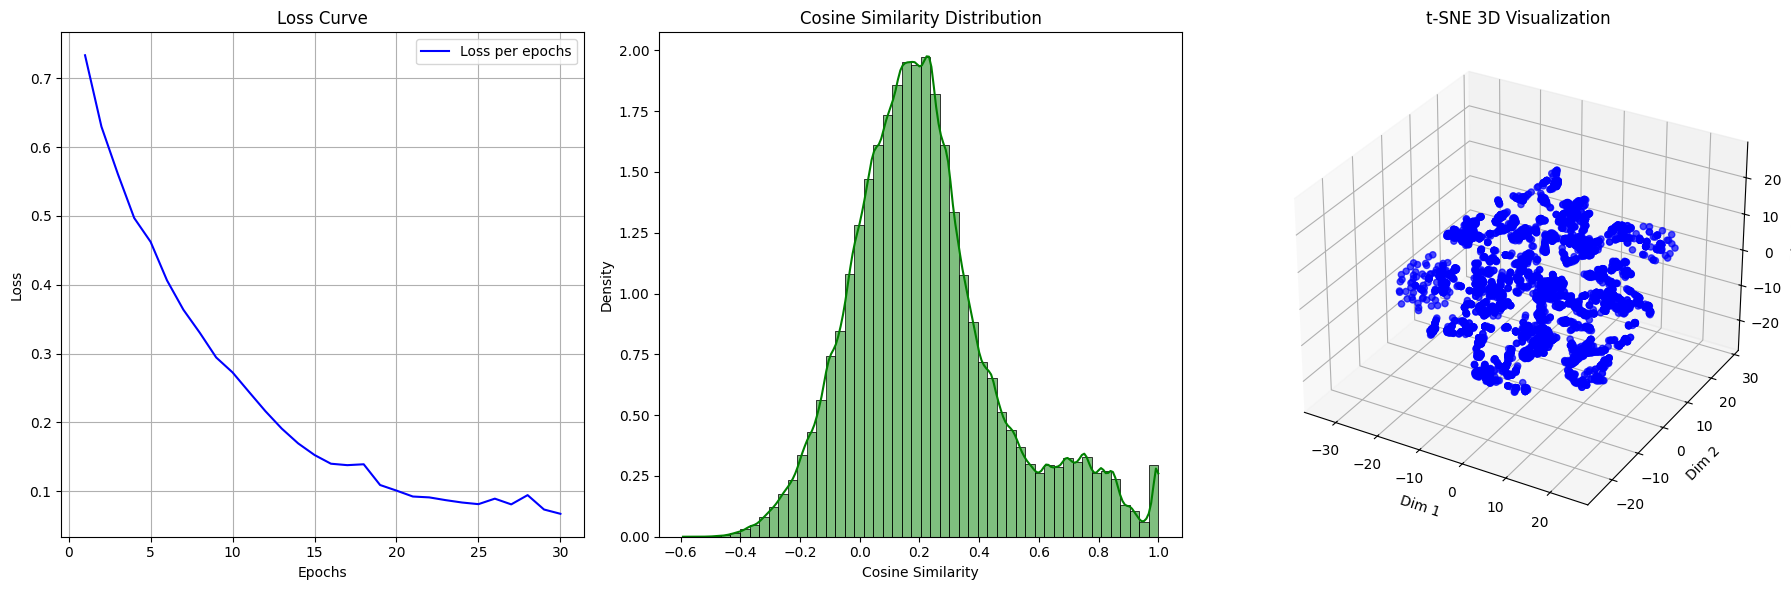

In [17]:
#Loss Curve
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Loss per epochs', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

#Cosine Similarity Histogram
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

#t-SNE in 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c='blue', alpha=0.7)
ax3.set_title('t-SNE 3D Visualization')
ax3.set_xlabel('Dim 1')
ax3.set_ylabel('Dim 2')
ax3.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

In [18]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
        
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [29]:
sample_dict = { 'company_size': '101-500',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations': 0,
                'pre_recorded_kit_counts': 0,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_amount_usd': 138.8,
                'days_since_login': '1641-5000'}

In [30]:
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,2956,101-500,0,2,1,0,60.0,0,1,1,0,0,1,0,138.8,1641-5000,0.845513
1,3034,101-500,0,2,1,0,60.0,0,1,1,0,0,1,0,138.8,1641-5000,0.845513
2,3872,101-500,0,2,1,0,60.0,0,1,2,0,0,0,0,69.4,1641-5000,0.837294
3,3575,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,13.9,1641-5000,0.812467
4,3562,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,13.9,1641-5000,0.812467


In [31]:
sample_dict2= { 'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 25,
                'pre_rec_interview_taken': 15,
                'subscription_amount_usd': 117.8,
                'days_since_login': '1641-5000'}

In [32]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,5854,101-500,1,1,1,1,58.0,0,0,6,78,8,156,32,34.7,511-580,0.686002
1,9597,1-25,1,1,1,0,1776.0,0,0,2,40,42,34,8,21.2,621-650,0.679696
2,5893,1-25,0,2,1,0,60.0,1,0,2,14,2,189,7,61.0,0-315,0.652955
3,9517,101-500,1,1,1,2,7099.0,0,0,7,55,11,28,21,99.6,621-650,0.621615
4,9743,101-500,0,1,1,1,141.0,0,0,1,23,6,33,3,1.8,621-650,0.610957


In [33]:
sample_dictt= { 'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 11,
                'wallet_amount': 101.0,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 15,
                'pre_rec_interview_taken': 15,
                'subscription_amount_usd': 208.8,
                'days_since_login': '1641-5000'}

In [34]:
recommend_from_sample_dict(sample_dictt, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,5335,500-1000,1,1,0,17,60.0,0,0,11,519,71,89,203,328.1,881-1200,0.833155
1,3678,26-100,1,2,1,13,60.0,0,1,33,485,27,92,215,208452.3,1351-1500,0.766939
2,6017,500-1000,1,1,1,10,1860.0,0,0,11,15,6,9,5,56.7,441-510,0.758365
3,9095,1-25,1,1,1,40,3053.0,0,0,4,518,292,181,135,64.2,621-650,0.755988
4,8501,26-100,1,1,1,14,1860.0,0,0,2,57,66,6,27,23.0,601-620,0.723925


In [35]:
sample_dict4= { 'company_size': '1-25',
                'is_premium': 1,
                'subscription_status': 1,
                'jobma_catcher_status': 1,
                'sub_users': 5,
                'wallet_amount': 500000.0,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 4,
                'pre_rec_interview_taken': 25,
                'subscription_amount_usd': 347.1,
                'days_since_login': '441-510'}
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,8520,1-25,1,1,1,1,2911.0,0,0,4,0,0,0,0,50.0,441-510,0.949368
1,10162,1-25,1,1,1,2,4074.0,0,0,1,27,8,2,9,0.6,441-510,0.947085
2,7054,1-25,1,1,1,0,660.0,0,0,2,0,0,0,0,21.2,441-510,0.933368
3,8535,1-25,1,1,1,0,14746.0,0,0,8,0,1,19,0,197.8,441-510,0.907127
4,8523,500-1000,1,1,1,1,124.0,0,0,5,1,1,3,1,51.9,441-510,0.894929


In [38]:
sample_dict5= { 'company_size': '1-25',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 16,
                'wallet_amount': 500000.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 5,
                'invitations':45,
                'pre_recorded_kit_counts': 58,
                'number_of_jobs_posted': 428,
                'pre_rec_interview_taken': 25725,
                'subscription_amount_usd': 300000,
                'days_since_login': '881-1200'}
recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,7151,26-100,0,2,1,1,60.0,0,1,1,444,22,3,348,347.1,881-1200,0.857576
1,6475,1-25,1,1,1,5,12.0,0,1,3,780,90,69,635,1041.3,441-510,0.804983
2,5856,26-100,1,2,1,4,60.0,0,1,2,230,7,11,151,416.4,881-1200,0.795516
3,5868,1-25,1,1,1,4,60.0,0,1,8,614,41,11,375,2637.9,881-1200,0.785648
4,5898,26-100,1,2,0,4,60.0,0,1,6,757,75,17,328,2082.6,881-1200,0.784045
